# Week 4: Advanced Predictive Model — Retail Sales Forecasting

**Project:** SafeX Solutions Internship — Advanced Predictive Model

**Dataset:** `retail_store_inventory.csv` (public retail inventory & sales dataset)

**Goal:** Build a complete, end-to-end forecasting pipeline for daily `Units Sold` — from
raw data to a tuned, evaluated model — and explain what actually drives
the predictions.

**What this notebook covers, in order:**
1. Load and explore the data
2. Clean the data (with reasons for every decision)
3. Engineer new features
4. Split into train/test sets (chronologically, since this is time-based data)
5. Compare 2–3 candidate models
6. Tune the best model's hyperparameters
7. Evaluate on the held-out test set and visualize results
8. Explain feature importance and summarize the findings


## 1. Load the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

random_state = 42

In [2]:
df = pd.read_csv("retail_store_inventory.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## 2. Explore the Data

Before touching anything, let's understand what we're working with: how big the dataset
is, what each column contains, whether anything is missing, and what the target variable
(`Units Sold`) looks like.

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (73100, 15)


In [4]:
print("---Column names---")
for column in df.columns:
    print(column)

---Column names---
Date
Store ID
Product ID
Category
Region
Inventory Level
Units Sold
Units Ordered
Demand Forecast
Price
Discount
Weather Condition
Holiday/Promotion
Competitor Pricing
Seasonality


In [5]:
print("----Data types----\n")
print(df.dtypes)

----Data types----

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object


In [6]:
print("---Missing values per column---")
print(df.isnull().sum())

---Missing values per column---
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
print(f"{'-----Summary Statistics-----':>68}")
df.describe(include = "all").T

                                        -----Summary Statistics-----


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,73100,731,2022-01-01,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store ID,73100,5,S001,14620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,73100,20,P0001,3655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,73100,5,Furniture,14699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,73100,4,East,18349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inventory Level,73100.0,NaN,NaN,NaN,274.469877,129.949514,50.0,162.0,273.0,387.0,500.0
Units Sold,73100.0,NaN,NaN,NaN,136.46487,108.919406,0.0,49.0,107.0,203.0,499.0
Units Ordered,73100.0,NaN,NaN,NaN,110.004473,52.277448,20.0,65.0,110.0,155.0,200.0
Demand Forecast,73100.0,NaN,NaN,NaN,141.49472,109.254076,-9.99,53.67,113.015,208.0525,518.55
Price,73100.0,NaN,NaN,NaN,55.135108,26.021945,10.0,32.65,55.05,77.86,100.0


**Note on the `Demand Forecast` column:** this dataset includes a `Demand Forecast`
column that looks tempting to use as a feature, but it is essentially a near-copy of
`Units Sold` with a small amount of noise added (it correlates with the target at
roughly r ≈ 0.997). Using it would be **data leakage** — the model would just be
learning to echo a number that, in the real world, we would not have in advance for a
day we haven't observed yet. It is left out of the feature set for this reason.

In [9]:
leakage_check = df[["Units Sold", "Demand Forecast"]].corr().iloc[0, 1]
print(f"Correlation between Units Sold and Demand Forecast: {leakage_check:.4f}")
print("\n-> Demand Forecast will be excluded from modeling to avoid data leakage.")

Correlation between Units Sold and Demand Forecast: 0.9969

-> Demand Forecast will be excluded from modeling to avoid data leakage.


In [10]:
df["Date"] = pd.to_datetime(df["Date"], errors = "coerce")
print(df["Date"].dtype)
df["Date"].head()

datetime64[ns]


0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
Name: Date, dtype: datetime64[ns]

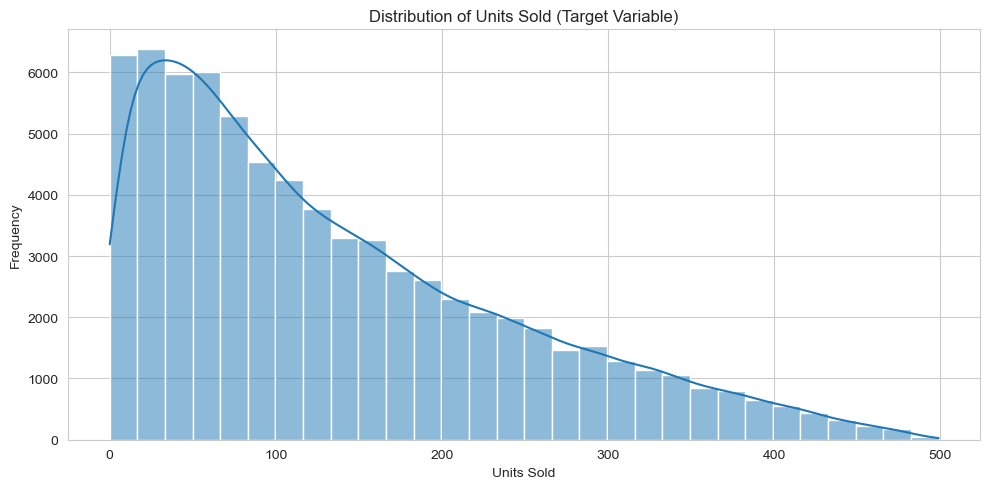

In [11]:
plt.figure(figsize = (10, 5))
sns.histplot(df["Units Sold"], bins = 30, kde = True)
plt.title("Distribution of Units Sold (Target Variable)")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [12]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("\nNumber of unique stores:", df["Store ID"].nunique())
print("Number of unique products:", df["Product ID"].nunique())

Start date: 2022-01-01 00:00:00
End date: 2024-01-01 00:00:00

Number of unique stores: 5
Number of unique products: 20


In [13]:
print("-----Data quality checks-----")
print("\nInvalid dates:", df["Date"].isna().sum())
print("Negative Units Sold:", (df["Units Sold"] < 0).sum())
print("Zero Units Sold:", (df["Units Sold"] == 0).sum())

-----Data quality checks-----

Invalid dates: 0
Negative Units Sold: 0
Zero Units Sold: 360


## 3. Clean the Data

Cleaning decisions and why each one is made:

- **Invalid dates** — none found, but the code below drops them defensively in case the
  dataset changes; a row with no date can't be used for a date-based forecast anyway.
- **Missing values** — none found in this dataset (checked above), so nothing is dropped
  or imputed here.
- **Negative `Units Sold`** — physically impossible for a sales count, so any such rows
  would be removed if present.
- **Duplicates** — checked and removed if present, since a duplicated transaction would
  double-count the same sale.

In [14]:
df_clean = df.copy()
before = len(df_clean)

# ---Ensure Date is proper datetime---
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors = "coerce")

# ---Drop rows with invalid dates (defensive — none expected)---
df_clean = df_clean.dropna(subset = ["Date"])

# ---Drop rows with a physically impossible negative Units Sold (defensive — none expected)---
df_clean = df_clean[df_clean["Units Sold"] >= 0]

# ---Drop exact duplicate rows---
df_clean = df_clean.drop_duplicates()

after = len(df_clean)
print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {after}")
print(f"Rows removed:         {before - after}")

Rows before cleaning: 73100
Rows after cleaning:  73100
Rows removed:         0


In [15]:
print("Cleaned dataset shape:", df_clean.shape)
print("\n---Remaining missing values---")
print(df_clean.isnull().sum())
print("\nRemaining duplicate rows:", df_clean.duplicated().sum())

Cleaned dataset shape: (73100, 15)

---Remaining missing values---
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Remaining duplicate rows: 0


## 4. Feature Engineering

Three groups of new features are added, each with a reason:

1. **Calendar features** (`Year`, `Month`, `Day`, `DayOfWeek`, `IsWeekend`) — retail sales
   are strongly seasonal and tied to the day of the week (weekend traffic differs from
   weekday traffic), so the model needs an explicit way to see calendar position.
2. **Lag features** (`Lag_1`, `Lag_7`) — yesterday's and last week's sales for the same
   store/product are often the single best predictor of today's sales 
3. **Rolling average** (`Rolling_7`) — a 7-day rolling average of past sales smooths out
   day-to-day noise and captures the recent demand trend for that store/product.

All lag and rolling values are computed **per store–product series** and shifted so that
today's value is never used to predict today's value (no leakage from the future).

In [16]:
df_feat = df_clean.copy()

# --- Calendar-based features ---
df_feat["Year"] = df_feat["Date"].dt.year
df_feat["Month"] = df_feat["Date"].dt.month
df_feat["Day"] = df_feat["Date"].dt.day
df_feat["DayOfWeek"] = df_feat["Date"].dt.dayofweek
df_feat["IsWeekend"] = df_feat["DayOfWeek"].isin([5, 6]).astype(int)

In [17]:
# ---Sort by store, product, and date so lag/rolling features line up correctly---
group_cols = ["Store ID", "Product ID"]
df_feat = df_feat.sort_values(group_cols + ["Date"]).reset_index(drop = True)

# ---Lag features: sales 1 day ago and 7 days ago for the same store/product---
df_feat["Lag_1"] = df_feat.groupby(group_cols)["Units Sold"].shift(1)
df_feat["Lag_7"] = df_feat.groupby(group_cols)["Units Sold"].shift(7)

In [18]:
#                  ---7-day rolling average of past sales---
# shift(1) first so the current day's own sales never leak into its own feature
df_feat["Rolling_7"] = (
    df_feat.groupby(group_cols)["Units Sold"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

### Forecasting Setup

The lag and rolling features use historical sales information only.
The evaluation represents sequential one-step-ahead forecasting, where
historical actual sales are available when generating lag features for
each subsequent date. This prevents future sales information from being
used to predict an earlier observation.

In [19]:
df_feat[
    [
        "Date", "Store ID", "Product ID", "Units Sold",
        "Year", "Month", "DayOfWeek", "IsWeekend",
        "Lag_1", "Lag_7", "Rolling_7",
    ]
].head(10)

,Date,Store ID,Product ID,Units Sold,Year,Month,DayOfWeek,IsWeekend,Lag_1,Lag_7,Rolling_7
0,2022-01-01,S001,P0001,127,2022,1,5,1,NaN,NaN,NaN
1,2022-01-02,S001,P0001,81,2022,1,6,1,127.0,NaN,NaN
2,2022-01-03,S001,P0001,5,2022,1,0,0,81.0,NaN,NaN
3,2022-01-04,S001,P0001,58,2022,1,1,0,5.0,NaN,NaN
4,2022-01-05,S001,P0001,147,2022,1,2,0,58.0,NaN,NaN
5,2022-01-06,S001,P0001,37,2022,1,3,0,147.0,NaN,NaN
6,2022-01-07,S001,P0001,107,2022,1,4,0,37.0,NaN,NaN
7,2022-01-08,S001,P0001,2,2022,1,5,1,107.0,127.0,80.285714
8,2022-01-09,S001,P0001,350,2022,1,6,1,2.0,81.0,62.428571
9,2022-01-10,S001,P0001,36,2022,1,0,0,350.0,5.0,100.857143


## 5. Train/Test Split

This is **Time-Series Data**, so a random split would leak future information into
training (the model could "see" a future date's neighbors while predicting the past).
Instead, the data is sorted by date and split chronologically: the earliest 80% of dates
are used for training, and the most recent 20% are held out for testing — this simulates
actually forecasting sales the model has never seen.

Rows without a full lag history (the first 7 days of each store/product series) are
dropped first, since `Lag_1`, `Lag_7`, and `Rolling_7` can't be computed for them.

In [20]:
df_model = df_feat.dropna(subset = ["Lag_1", "Lag_7", "Rolling_7"]).copy()

print("Shape before dropping rows with no lag history:", df_feat.shape)
print("Shape after dropping rows with no lag history: ", df_model.shape)

Shape before dropping rows with no lag history: (73100, 23)
Shape after dropping rows with no lag history:  (72400, 23)


In [21]:
df_model = df_model.sort_values("Date").reset_index(drop = True)

cutoff_date = df_model["Date"].quantile(0.80)

train_data = df_model[df_model["Date"] < cutoff_date].copy()
test_data = df_model[df_model["Date"] >= cutoff_date].copy()

print("Cutoff date:", cutoff_date)
print("Training rows:", train_data.shape[0])
print("Testing rows: ", test_data.shape[0])
print()
print("Training date range:", train_data["Date"].min(), "to", train_data["Date"].max())
print("Testing date range: ", test_data["Date"].min(), "to", test_data["Date"].max())

Cutoff date: 2023-08-10 00:00:00
Training rows: 57900
Testing rows:  14500

Training date range: 2022-01-08 00:00:00 to 2023-08-09 00:00:00
Testing date range:  2023-08-10 00:00:00 to 2024-01-01 00:00:00


## 6. Prepare Features and Target

`Demand Forecast` is intentionally excluded. Categorical
columns are converted to dummy variables, and the train/test dummy columns are aligned
so both sets have exactly the same columns in the same order.

In [22]:
target = "Units Sold"

feature_columns = [
    "Store ID", "Product ID", "Category", "Region",
    "Inventory Level", "Units Ordered", "Price", "Discount",
    "Weather Condition", "Holiday/Promotion", "Competitor Pricing", "Seasonality",
    "Year", "Month", "Day", "DayOfWeek", "IsWeekend",
    "Lag_1", "Lag_7", "Rolling_7",
]

X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()

y_train = train_data[target].copy()
y_test = test_data[target].copy()

In [23]:
X_train = pd.get_dummies(X_train, drop_first = True)
X_test = pd.get_dummies(X_test, drop_first = True)

X_train, X_test = X_train.align(X_test, join = "left", axis = 1, fill_value = 0)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (57900, 50)
X_test shape:  (14500, 50)
y_train shape: (57900,)
y_test shape:  (14500,)


## 7. Compare Candidate Models

Three models representing different approaches are trained and compared on the same
train/test split, using **MAE**, **RMSE**, and **R²** — the standard metrics for a
regression (forecasting) problem:

- **Ridge Regression** — a simple, fast linear baseline
- **Random Forest Regressor** — a tree-based ensemble that can capture non-linear patterns
- **Gradient Boosting Regressor** — a boosted tree ensemble, often stronger than a single
  Random Forest

Whichever performs best here is carried forward into hyperparameter tuning.

In [24]:
random_state = 42

candidate_models = {
    "Ridge Regression": Ridge(alpha = 1.0, random_state = random_state),
    "Random Forest": RandomForestRegressor(n_estimators = 100, max_depth = 20, random_state = random_state, n_jobs = -1),
    "Gradient Boosting": GradientBoostingRegressor(random_state = random_state),
}

comparison_rows = []

for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    comparison_rows.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f"{name:<20} MAE = {mae:5.2f}   RMSE = {rmse:5.2f}   R2 = {r2:5.3f}")

model_comparison = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop = True)
model_comparison

Ridge Regression     MAE = 68.62   RMSE = 87.61   R2 = 0.344
Random Forest        MAE = 69.03   RMSE = 88.48   R2 = 0.331
Gradient Boosting    MAE = 68.67   RMSE = 87.72   R2 = 0.342


,Model,MAE,RMSE,R2
0,Ridge Regression,68.616774,87.605195,0.344064
1,Gradient Boosting,68.667653,87.721301,0.342324
2,Random Forest,69.031628,88.484668,0.330828


## 8. Hyperparameter Tuning

The best-performing model from the comparison above is tuned with
`RandomizedSearchCV`, using `TimeSeriesSplit` (instead of ordinary K-fold) so that every
validation fold during tuning is still strictly *after* its training fold in time — this
keeps the tuning process honest about it being a forecasting problem.

In [25]:
best_model_name = model_comparison.iloc[0]["Model"]
print("Best model from comparison:", best_model_name)

Best model from comparison: Ridge Regression


In [26]:
tscv = TimeSeriesSplit(n_splits = 5)

if best_model_name == "Ridge Regression":
    base_model = Ridge(random_state = random_state)
    param_distributions = {"alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 200.0]}
    
elif best_model_name == "Random Forest":
    base_model = RandomForestRegressor(random_state = random_state, n_jobs = -1)
    param_distributions = {
        "n_estimators": [100, 200, 300],
        "max_depth": [10, 20, 30, None],
        "min_samples_leaf": [1, 2, 4],
    }
    
else:
    base_model = GradientBoostingRegressor(random_state = random_state)
    param_distributions = {
        "n_estimators": [100, 200, 300],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.01, 0.05, 0.1],
    }

search = RandomizedSearchCV(
    base_model,
    param_distributions = param_distributions,
    n_iter = 10,
    cv = tscv,
    scoring = "neg_root_mean_squared_error",
    random_state = random_state,
    n_jobs = -1,
)
search.fit(X_train, y_train)

print("Best parameters found:", search.best_params_)
best_model = search.best_estimator_

c:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 7 is smaller than n_iter=10. Running 7 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters found: {'alpha': 200.0}


In [27]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("---Tuned model evaluation on the held-out test set---")
print(f"{'Mean Absolute Error:':<28} {mae:.2f}")
print(f"{'Root Mean Squared Error:':<28} {rmse:.2f}")
print(f"{'R-squared:':<28} {r2:.3f}")

tuned_metrics = pd.DataFrame([{
    "Model": f"{best_model_name} (tuned)",
    "Best Params": str(search.best_params_),
    "MAE": mae, "RMSE": rmse, "R2": r2,
}])
tuned_metrics

---Tuned model evaluation on the held-out test set---
Mean Absolute Error:         68.62
Root Mean Squared Error:     87.60
R-squared:                   0.344


,Model,Best Params,MAE,RMSE,R2
0,Ridge Regression (tuned),{'alpha': 200.0},68.615753,87.603937,0.344083


## 9. Visualize Results

In [28]:
results = pd.DataFrame({
    "Date": test_data["Date"].values,
    "Actual Units Sold": y_test.values,
    "Predicted Units Sold": y_pred,
})
results = results.sort_values("Date")
results["Error"] = results["Actual Units Sold"] - results["Predicted Units Sold"]
results["Absolute Error"] = results["Error"].abs()
results.head(10)

,Date,Actual Units Sold,Predicted Units Sold,Error,Absolute Error
0,2023-08-10,59,26.969853,32.030147,32.030147
72,2023-08-10,211,173.041201,37.958799,37.958799
71,2023-08-10,37,27.691962,9.308038,9.308038
70,2023-08-10,105,68.569847,36.430153,36.430153
69,2023-08-10,459,246.527107,212.472893,212.472893
68,2023-08-10,17,73.633066,-56.633066,56.633066
67,2023-08-10,49,31.902296,17.097704,17.097704
66,2023-08-10,120,80.610403,39.389597,39.389597
65,2023-08-10,211,119.770027,91.229973,91.229973
64,2023-08-10,272,184.952865,87.047135,87.047135


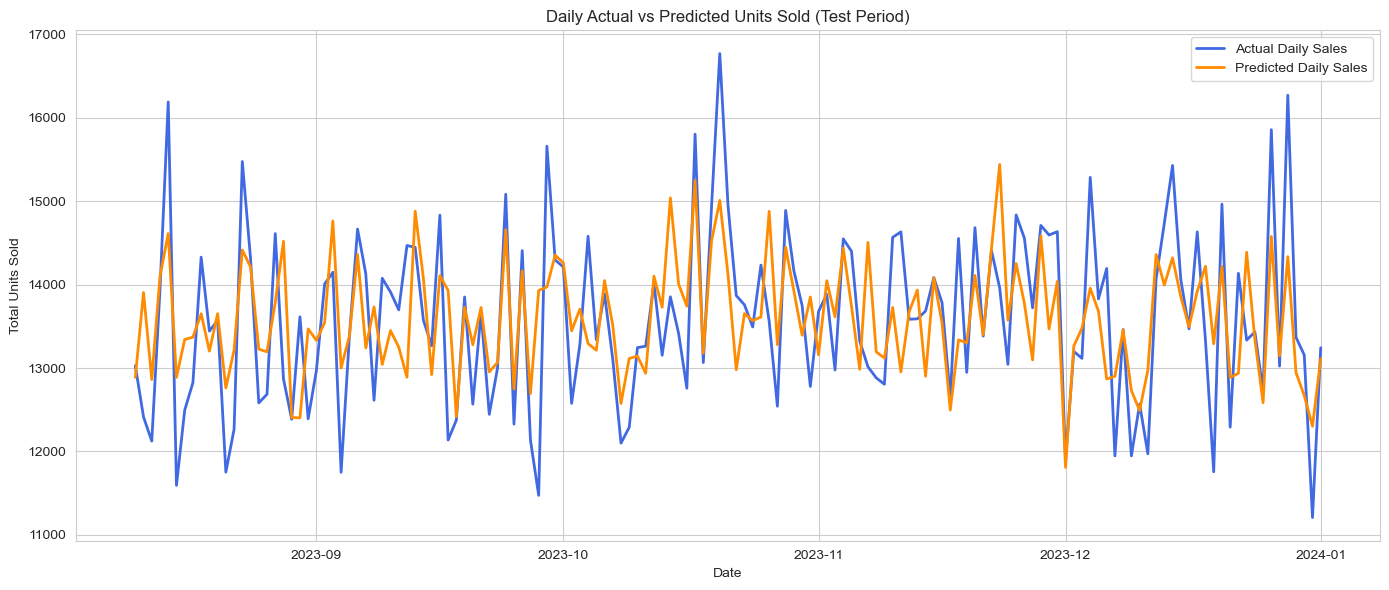

In [29]:
daily_results = (
    results.groupby("Date")
    .agg({"Actual Units Sold": "sum", "Predicted Units Sold": "sum"})
    .reset_index()
)

plt.figure(figsize = (14, 6))
plt.plot(
        daily_results["Date"], 
        daily_results["Actual Units Sold"],
        label = "Actual Daily Sales",
        color = "royalblue",
        linewidth = 2
)

plt.plot(
        daily_results["Date"],
        daily_results["Predicted Units Sold"],
        label = "Predicted Daily Sales",
        color = "darkorange",
        linewidth = 2
)
plt.title("Daily Actual vs Predicted Units Sold (Test Period)")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

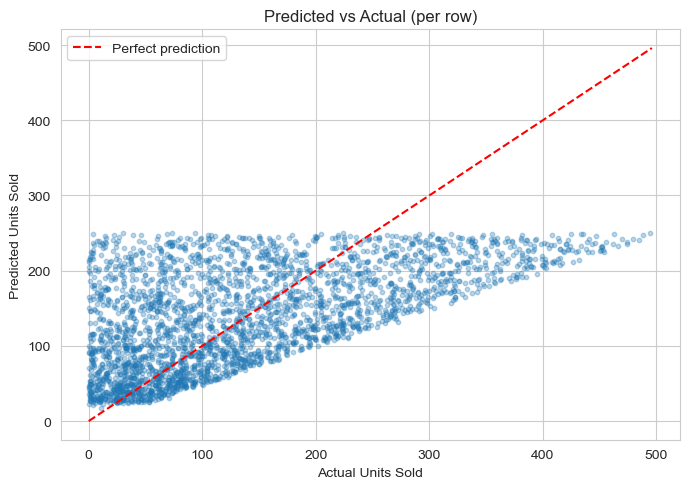

In [35]:
plt.figure(figsize = (7, 5))

sample = results.sample(min(3000, len(results)), random_state = random_state)
plt.scatter(sample["Actual Units Sold"], sample["Predicted Units Sold"], alpha = 0.3, s = 10)
lims = [0, max(results["Actual Units Sold"].max(), results["Predicted Units Sold"].max())]

plt.plot(
        lims,
        lims,  
        color = "red",
        linestyle = "--",
        label = "Perfect prediction"
)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Predicted vs Actual (per row)")
plt.legend()
plt.tight_layout()
plt.show()

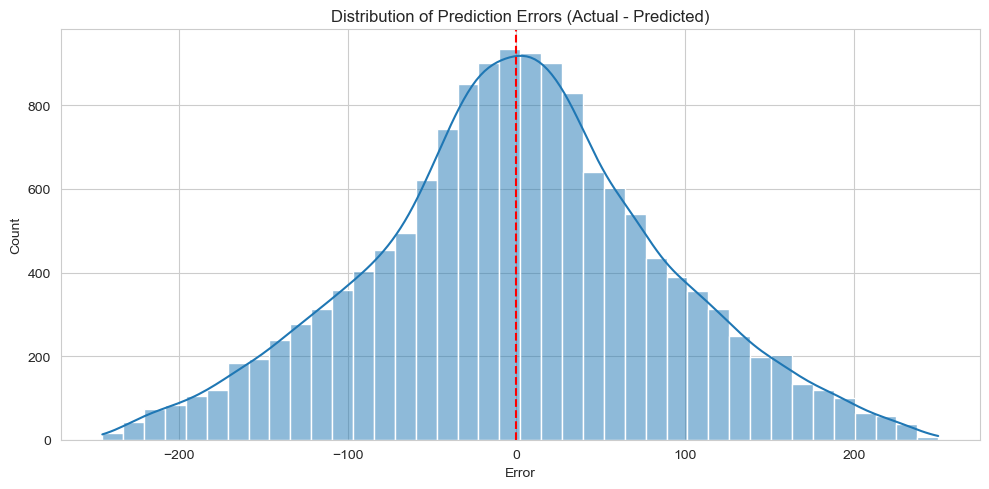

In [31]:
plt.figure(figsize = (10, 5))

sns.histplot(results["Error"], bins = 40, kde = True)
plt.axvline(
        0,
        color = "red",
        linestyle = "--"
)
plt.title("Distribution of Prediction Errors (Actual - Predicted)")
plt.xlabel("Error")
plt.tight_layout()
plt.show()

## 10. Feature Importance

In [32]:
if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
    
elif hasattr(best_model, "coef_"):
    importance_values = np.abs(best_model.coef_)
    
else:
    importance_values = np.zeros(X_train.shape[1])

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance_values,
}).sort_values("Importance", ascending = False).reset_index(drop = True)

importance_df.head(15)

,Feature,Importance
0,Product ID_P0005,2.275365
1,Product ID_P0017,2.213814
2,IsWeekend,2.084116
3,Product ID_P0008,2.004892
4,Product ID_P0003,1.624697
5,Weather Condition_Sunny,1.276738
6,Store ID_S005,1.241754
7,Store ID_S004,1.138816
8,Store ID_S003,1.115394
9,Product ID_P0010,1.088780


C:\Users\User\AppData\Local\Temp\ipykernel_15552\643721059.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


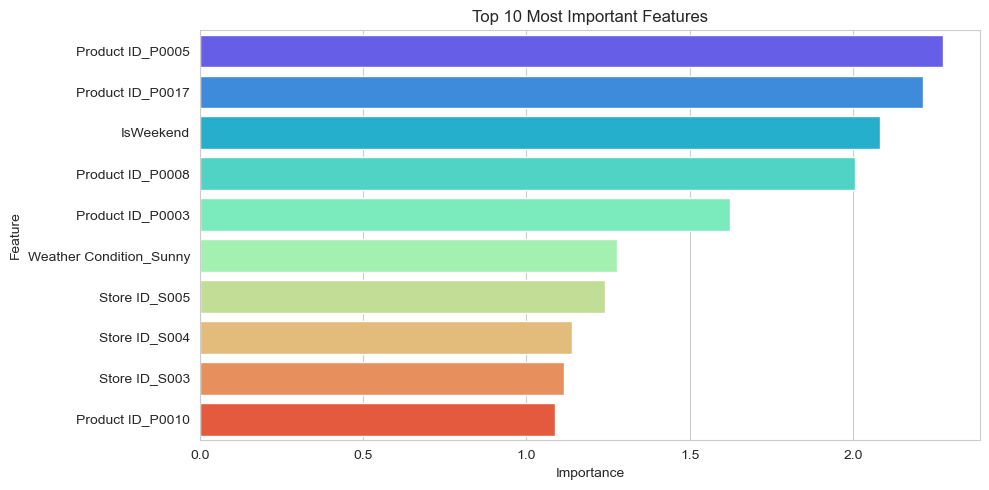

In [36]:
top_features = importance_df.head(10)

plt.figure(figsize = (10, 5))
sns.barplot(
        y = top_features["Feature"],
        x = top_features["Importance"],
        palette = "rainbow"
)
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

Within the fitted Ridge model, product and store indicators and the 
IsWeekend feature had relatively large coefficient magnitudes. Among 
the unscaled numeric variables, Inventory Level and Year showed the 
largest coefficient magnitudes. These results describe how the model 
uses the available features to make predictions and should not be 
interpreted as proof of causal business drivers. Because Ridge 
coefficients are sensitive to feature scale, categorical and numeric 
features should not be treated as directly comparable measures of 
business importance.

## 11. Findings — What Actually Drives the Prediction

- **Ridge Regression** was the best of the three models, though only barely — tuned test
  results: **MAE ≈ 68.6**, **RMSE ≈ 87.6**, **R² ≈ 0.34**.

- **R² ≈ 0.34** means the model explains about a third of the daily variation in
  `Units Sold`; the rest likely comes from factors the data doesn't capture (real
  promotions, stockouts, actual weather). All three models scored similarly, so the
  ceiling is set by the data, not the algorithm.

- **Biggest drivers:** which product/store it is, and `IsWeekend` — though this is
  partly a Ridge coefficient-scale effect (0/1 dummies vs. unscaled numerics), not a
  clean business ranking. Among numeric features, `Inventory Level` and `Year` matter
  most; `Price`, `Discount`, and `Competitor Pricing` barely register.

- **Lag/rolling features (`Lag_1`, `Lag_7`, `Rolling_7`) had near-zero importance** —
  daily demand here behaves close to random noise rather than a trending series.
  
- **Takeaway:** a simpler model on product/store identity, weekend flag, and inventory
  level would likely perform almost as well as the full pipeline for this dataset.

## 12. Save Results

In [34]:
results.to_csv("actual_vs_predicted_sales.csv", index = False)
daily_results.to_csv("daily_forecasting_results.csv", index = False)
model_comparison.to_csv("model_comparison.csv", index = False)
tuned_metrics.to_csv("tuned_metrics.csv", index = False)
importance_df.to_csv("feature_importance.csv", index = False)

print("---All results saved successfully---\n")
print(" 1. actual_vs_predicted_sales.csv")
print(" 2. daily_forecasting_results.csv")
print(" 3. model_comparison.csv")
print(" 4. tuned_metrics.csv")
print(" 5. feature_importance.csv")

---All results saved successfully---

 1. actual_vs_predicted_sales.csv
 2. daily_forecasting_results.csv
 3. model_comparison.csv
 4. tuned_metrics.csv
 5. feature_importance.csv
